In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score

In [2]:
data = pd.read_csv("C:/Users/jayit/OneDrive/Documents/Project/Argo_and_All_Data.csv")

In [3]:
data.head()

,LON,LAT,Year,Month,Day,AirT,UWIND,VWIND,WIND,SWRAD,LWRAD,LATHF,SENHF,NETHF,SST,SSS,D23,SSVEL,SLD
0,85.499,15.298,2011,1,1,25.534,-3.871,-1.185,4.048,-0.000,-75.936,-116.422,-7.722,-200.080,27.366,33.497,127.691,1538.392,70
1,88.302,9.739,2011,1,1,25.630,-4.712,-1.741,5.024,-0.000,-35.961,-111.057,-15.083,-162.102,28.132,34.130,146.711,1540.772,50
2,85.694,9.306,2011,1,1,25.614,-4.706,-1.344,4.894,665.526,-42.262,-108.105,-3.015,512.143,NaN,NaN,144.044,NaN,27
3,89.982,11.161,2011,1,2,25.371,-5.666,-2.038,6.022,100.582,-33.962,-113.438,-19.062,-65.881,27.883,33.396,139.687,1539.446,45
4,85.495,10.955,2011,1,3,25.243,-7.224,-4.540,8.532,-0.000,-35.937,-151.676,-23.595,-211.208,27.712,33.014,138.328,1538.660,40


In [4]:
df=data.dropna()
df

,LON,LAT,Year,Month,Day,AirT,UWIND,VWIND,WIND,SWRAD,LWRAD,LATHF,SENHF,NETHF,SST,SSS,D23,SSVEL,SLD
0,85.49900,15.298000,2011,1,1,25.534,-3.871,-1.185,4.048,-0.000,-75.936,-116.422,-7.722,-200.080,27.366,33.497,127.691,1538.392,70
1,88.30200,9.739000,2011,1,1,25.630,-4.712,-1.741,5.024,-0.000,-35.961,-111.057,-15.083,-162.102,28.132,34.130,146.711,1540.772,50
3,89.98200,11.161000,2011,1,2,25.371,-5.666,-2.038,6.022,100.582,-33.962,-113.438,-19.062,-65.881,27.883,33.396,139.687,1539.446,45
4,85.49500,10.955000,2011,1,3,25.243,-7.224,-4.540,8.532,-0.000,-35.937,-151.676,-23.595,-211.208,27.712,33.014,138.328,1538.660,40
6,87.87100,14.038000,2011,1,4,26.440,-8.131,-5.485,9.809,357.742,-42.892,-276.453,-13.133,25.263,27.490,32.844,133.101,1537.984,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14241,84.05400,10.169000,2020,12,29,26.866,-5.382,-2.492,5.931,626.547,-45.111,-87.921,-6.094,487.421,27.667,33.494,136.279,1539.066,36
14242,87.64900,15.012000,2020,12,29,25.997,-4.347,-4.278,6.099,62.918,-30.417,-152.537,-12.585,-132.620,27.402,33.017,129.507,1537.967,79
14243,88.62767,8.314662,2020,12,30,27.187,-5.810,-1.460,5.991,182.819,-46.693,-124.113,-13.168,-1.155,28.678,34.011,155.738,1541.841,74
14244,88.79500,10.344000,2020,12,31,27.360,-5.078,-4.438,6.744,203.434,-51.379,-176.908,-7.862,-32.717,28.343,33.876,149.373,1540.967,51


In [5]:
df = df.drop(df[df['SLD'] <= 9].index)
df

,LON,LAT,Year,Month,Day,AirT,UWIND,VWIND,WIND,SWRAD,LWRAD,LATHF,SENHF,NETHF,SST,SSS,D23,SSVEL,SLD
0,85.49900,15.298000,2011,1,1,25.534,-3.871,-1.185,4.048,-0.000,-75.936,-116.422,-7.722,-200.080,27.366,33.497,127.691,1538.392,70
1,88.30200,9.739000,2011,1,1,25.630,-4.712,-1.741,5.024,-0.000,-35.961,-111.057,-15.083,-162.102,28.132,34.130,146.711,1540.772,50
3,89.98200,11.161000,2011,1,2,25.371,-5.666,-2.038,6.022,100.582,-33.962,-113.438,-19.062,-65.881,27.883,33.396,139.687,1539.446,45
4,85.49500,10.955000,2011,1,3,25.243,-7.224,-4.540,8.532,-0.000,-35.937,-151.676,-23.595,-211.208,27.712,33.014,138.328,1538.660,40
6,87.87100,14.038000,2011,1,4,26.440,-8.131,-5.485,9.809,357.742,-42.892,-276.453,-13.133,25.263,27.490,32.844,133.101,1537.984,61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14241,84.05400,10.169000,2020,12,29,26.866,-5.382,-2.492,5.931,626.547,-45.111,-87.921,-6.094,487.421,27.667,33.494,136.279,1539.066,36
14242,87.64900,15.012000,2020,12,29,25.997,-4.347,-4.278,6.099,62.918,-30.417,-152.537,-12.585,-132.620,27.402,33.017,129.507,1537.967,79
14243,88.62767,8.314662,2020,12,30,27.187,-5.810,-1.460,5.991,182.819,-46.693,-124.113,-13.168,-1.155,28.678,34.011,155.738,1541.841,74
14244,88.79500,10.344000,2020,12,31,27.360,-5.078,-4.438,6.744,203.434,-51.379,-176.908,-7.862,-32.717,28.343,33.876,149.373,1540.967,51


In [6]:
x = df[['LON','LAT','Month','AirT','UWIND','VWIND','WIND','SWRAD','LWRAD','LATHF','SENHF','NETHF','SST','SSS','D23','SSVEL']]
y = df['SLD']

In [7]:
scaler = StandardScaler()
x = scaler.fit_transform(x)

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [9]:
#Building the ANN
    #Initializing the ANN
ann=tf.keras.models.Sequential()

In [54]:
    #Adding the input layer and the first hidden layer
    #relu:rectifier activation function
ann.add(tf.keras.layers.Dense(units=74,activation='relu'))  

In [55]:
    #Adding the second hidden layer
ann.add(tf.keras.layers.Dense(units=72,activation='relu'))  

In [56]:
    #Adding the output layer
ann.add(tf.keras.layers.Dense(units=1))     

In [57]:
#Training the ANN
    #Compiling the ANN
    #adam:Adaptive Moment Estimation
ann.compile(optimizer='adam',loss='mean_squared_error',metrics=['mae'])

In [58]:
    #Training the ANN on the Training set
ann.fit(x_train,y_train,batch_size=32,epochs=50)

Epoch 1/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 782.3995 - mae: 20.1942
Epoch 2/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 115.6919 - mae: 8.2791
Epoch 3/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 112.3408 - mae: 8.2378
Epoch 4/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 113.1298 - mae: 8.2325
Epoch 5/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 114.0183 - mae: 8.3132
Epoch 6/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 111.6512 - mae: 8.1532
Epoch 7/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 111.6647 - mae: 8.1719
Epoch 8/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 111.9509 - mae: 8.1422
Epoch 9/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 115.2757 - mae: 8.3228
Epoch 10/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 108.4647 - mae: 8.0795
Epoch 11/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 115.9974 - mae: 8.3435
Epoch 12/50
241/241 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 112.2846 - mae: 8.2355


In [59]:
y_pred=ann.predict(x_test)

61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [60]:
y_pred_filtered = np.clip(y_pred, a_min=None, a_max=150)

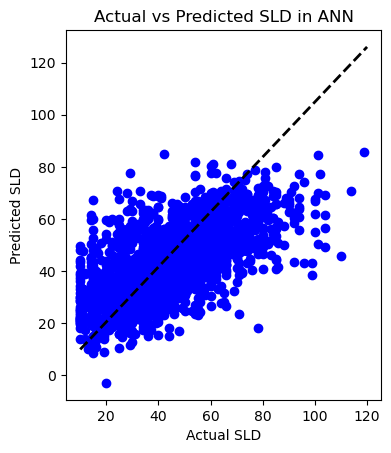

In [25]:
fig, ax = plt.subplots()

#create simple line plot
ax.scatter(y_test, y_pred_filtered, color='blue')
plt.plot([y.min(), 120], [y.min(), y.max()], 'k--', lw=2)
#plt.plot([y.min(), 100], [y.min(), 110], 'k--', lw=2)

plt.xlabel('Actual SLD')
plt.ylabel('Predicted SLD')
plt.title('Actual vs Predicted SLD in ANN')


#attempt to set aspect ratio to 1
ax.set_aspect(1)

#display plot
plt.show()

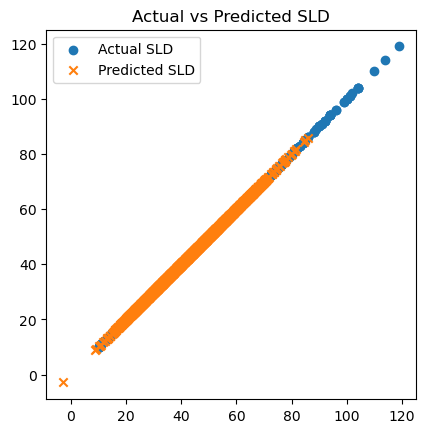

In [26]:
fig, ax = plt.subplots()
ax.set_aspect(1)
ax.scatter(y_test,y_test, label='Actual SLD', marker='o')
ax.scatter(y_pred_filtered,y_pred_filtered, label='Predicted SLD', marker='x')
plt.title('Actual vs Predicted SLD')
plt.legend()
plt.show()

In [27]:
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_filtered))

Mean Absolute Error: 11.56132020997333


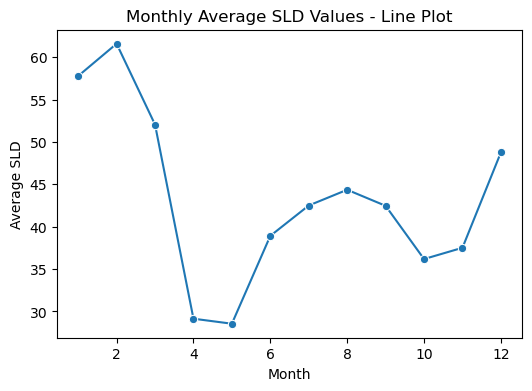

In [28]:
monthly_avg = df.groupby('Month')['SLD'].mean().reset_index()
plt.figure(figsize=(6, 4))
sns.lineplot(x='Month', y='SLD', data=monthly_avg, marker='o')
plt.title('Monthly Average SLD Values - Line Plot')
plt.xlabel('Month')
plt.ylabel('Average SLD')
plt.show()

In [29]:
sld_min = df['SLD'].min()
sld_max = df['SLD'].max()
sld_mean = df['SLD'].mean()

print(f"SLD range: {sld_min} to {sld_max}")
print(f"Mean SLD value: {sld_mean}")

# Calculate relative error
relative_error = 11.5 / sld_mean * 100
print(f"Relative Error: {relative_error:.2f}%")

SLD range: 10 to 126
Mean SLD value: 44.175438596491226
Relative Error: 26.03%
